In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})



# Select Files


In [2]:
file_name = "WA0089_850V_20MHz_Cold_led1"
# file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = 1

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5
Number of files loaded: 1


### if and where to save plots

In [3]:
save_plots = False
save_dir = 'plots_analysis'
file_nickname = file_name

# Configuration

In [4]:
cfg = load_config("config_default.yml", file_name)
print(cfg)

[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 80.0)
fit_nbins = 250



In [5]:
chunk_size = 512 #4096

baseline_window_width_ns          = cfg.general.baseline_window_width_ns
integration_window_ns             = cfg.general.integration_window_ns

# refactor: make this one variable
peak_search_window_ns             = cfg.general.peak_search_window_ns  
allowed_peak_window_ns            = cfg.general.allowed_peak_window_ns
# peak_time_window_mV = 
out_of_window_peak_voltage_max_mV = cfg.general.out_of_window_peak_voltage_max_mV
# peak_finding_threshold_mV = 

selection_peak_threshold_max_mV        = cfg.general.global_peak_voltage_max_mV
# baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + config["baseline_window_width_ns"]))



In [6]:
max_sample_events = 1

sample = read_waveform_sample(files, max_events=max_sample_events)
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


# 2. Full Sample


In [7]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    baseline_subtraction=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None,
    high_limit_mV=None,
    margin_mV=0.0,
    max_saturated_samples=0
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]
# baseline_mV = prerocessed_data["baseline_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}

prerocessed_data.keys()



Preprocessed sample: (31677, 1601)
Efficiency of saturation cut: 99.984 %


dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

In [8]:
prerocessed_data['event_info'].keys()

dict_keys(['is_saturated', 'n_saturated_samples', 'baseline_mean_mV', 'baseline_rms_mV', 'baseline_slope_mV_per_ns'])

[]

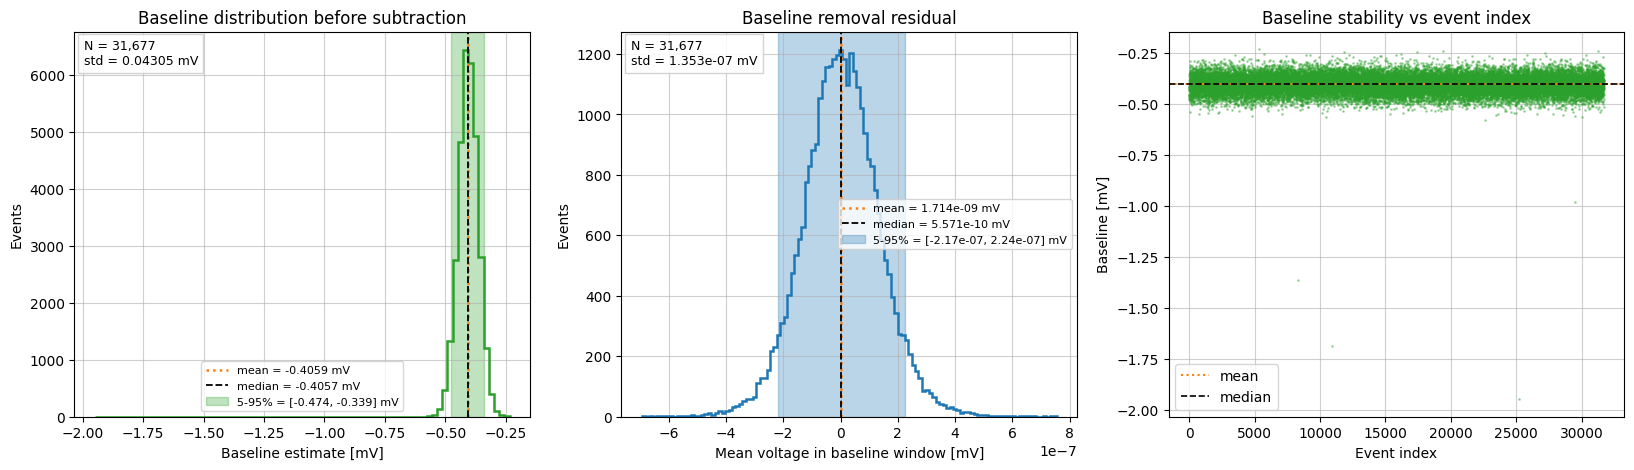

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_baseline_quality(axes, time_ns, prerocessed_data['event_info']['baseline_mean_mV'], voltage_mV, baseline_window_ns)
save_plot(fig, save_plots, save_dir, file_nickname, f"basline_quality",  Nevents=max_sample_events)

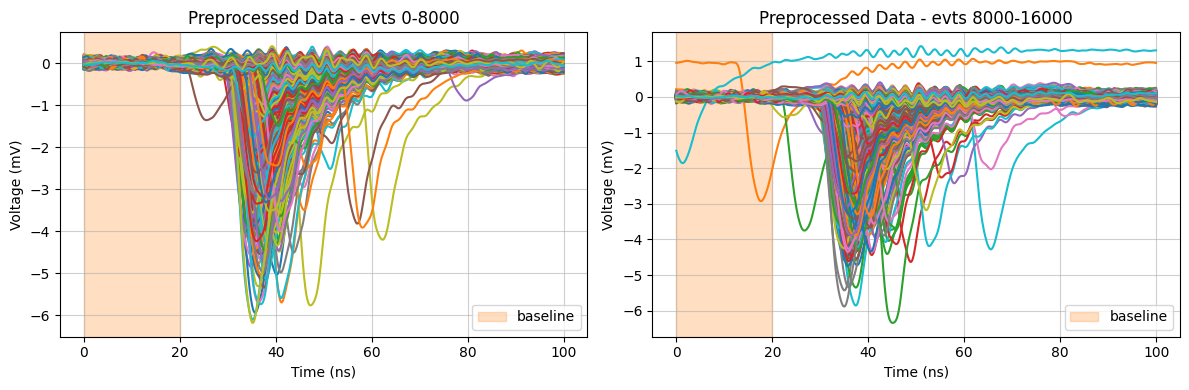

In [10]:
n_to_plot = 8000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, voltage_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, voltage_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"wfs_raw_vs_bs", Nevents=n_to_plot);

# Selection

In [11]:
df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)
df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


,peak_time_ns,peak_idx,peak_amplitude_mV,fwhm_ns,peak_width_ns,rise_time_10_90_ns,fall_time_90_10_ns,cfd10_rise_ns,cfd20_rise_ns,cfd30_rise_ns,...,charge_cfd50_window_mV_ns,n_peaks,second_peak_time_ns,second_peak_amplitude_mV,peak_separation_ns,event_id,baseline_mean_mV,baseline_rms_mV,baseline_slope_mV_per_ns,snr
0,48.845558,782,0.154285,70.5000,1.560707,42.199937,0.532167,6.403388,8.529605,28.253228,...,0.342312,29,60.220558,0.127556,11.3750,0,-0.417220,0.022482,-0.001616,6.862754
1,92.033058,1473,0.188668,42.9375,1.841262,91.338668,NaN,-0.029442,0.408747,48.570819,...,3.794535,63,92.158058,0.188455,0.1250,1,-0.354397,0.022482,0.003139,8.391824
2,57.345558,918,0.120700,20.3125,1.777084,48.114020,0.595384,9.020464,9.512987,12.433460,...,-2.513309,24,48.845558,0.086273,-8.5000,2,-0.399058,0.027165,-0.002721,4.443178
3,28.658058,459,0.157816,51.5000,2.813405,25.345305,1.105513,2.930133,6.146375,10.582930,...,-4.199344,16,19.470558,0.133653,-9.1875,3,-0.439135,0.064233,-0.001729,2.456924
4,48.845558,782,0.105275,36.3750,1.553911,39.622366,0.457094,9.044411,9.238400,9.487635,...,-1.933412,31,60.283058,0.086672,11.4375,4,-0.459601,0.036709,-0.005404,2.867852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31672,49.158058,787,0.217527,37.8125,1.651498,39.613671,0.731168,9.269205,22.715601,23.150449,...,2.654093,22,60.283058,0.166635,11.1250,31672,-0.385412,0.020334,-0.002280,10.697623
31673,33.033058,529,0.173565,48.3750,8.305761,16.145550,2.543906,16.337645,16.789123,17.181924,...,2.384803,40,32.908058,0.173137,-0.1250,31673,-0.408205,0.034971,-0.005231,4.963080
31674,49.033058,785,0.175635,49.0000,1.583266,36.239575,0.684359,12.554338,12.979967,16.253075,...,4.044895,31,65.908058,0.161308,16.8750,31674,-0.358022,0.027580,-0.002939,6.368097
31675,49.220558,788,0.175177,70.8125,1.600864,48.965412,0.734325,-0.029442,0.214581,2.997021,...,3.652155,62,40.970558,0.150800,-8.2500,31675,-0.389272,0.029175,0.003554,6.004360


In [12]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject

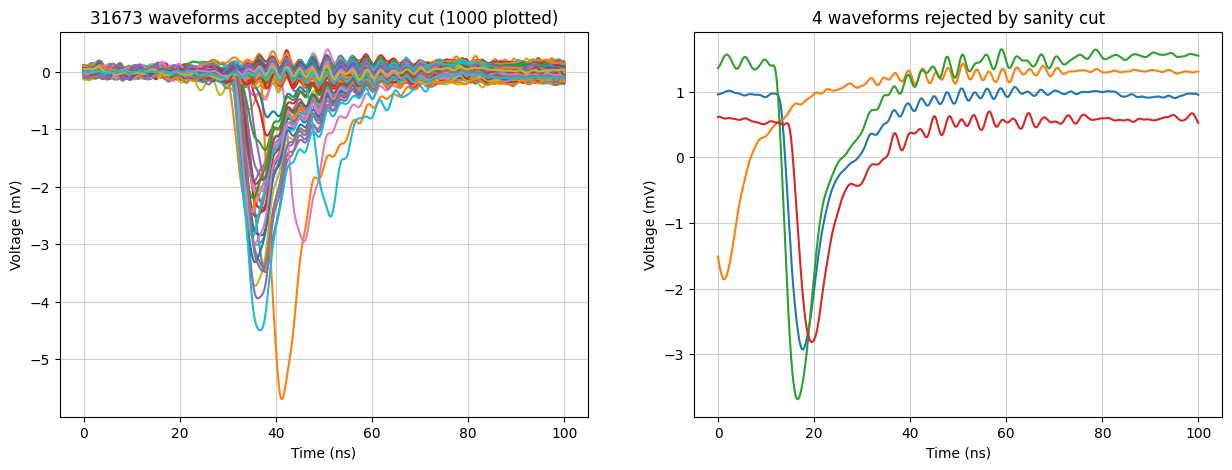

In [13]:
nEvts_plot = 1000
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()
rejected_waveforms = voltage_mV[sanity_mask_reject.values]
selected_waveforms = voltage_mV[sanity_mask_keep.values]

add_plot_waveforms(axes[0], time_ns, selected_waveforms[:nEvts_plot], title=f"{len(selected_waveforms)} waveforms accepted by sanity cut ({nEvts_plot} plotted)")
add_plot_waveforms(axes[1], time_ns, rejected_waveforms, title=f"{len(rejected_waveforms)} waveforms rejected by sanity cut")

In [14]:
df_sel = df[sanity_mask_keep].copy()
# waveforms_sel = voltage_mV[df_sel["event_id"].values]

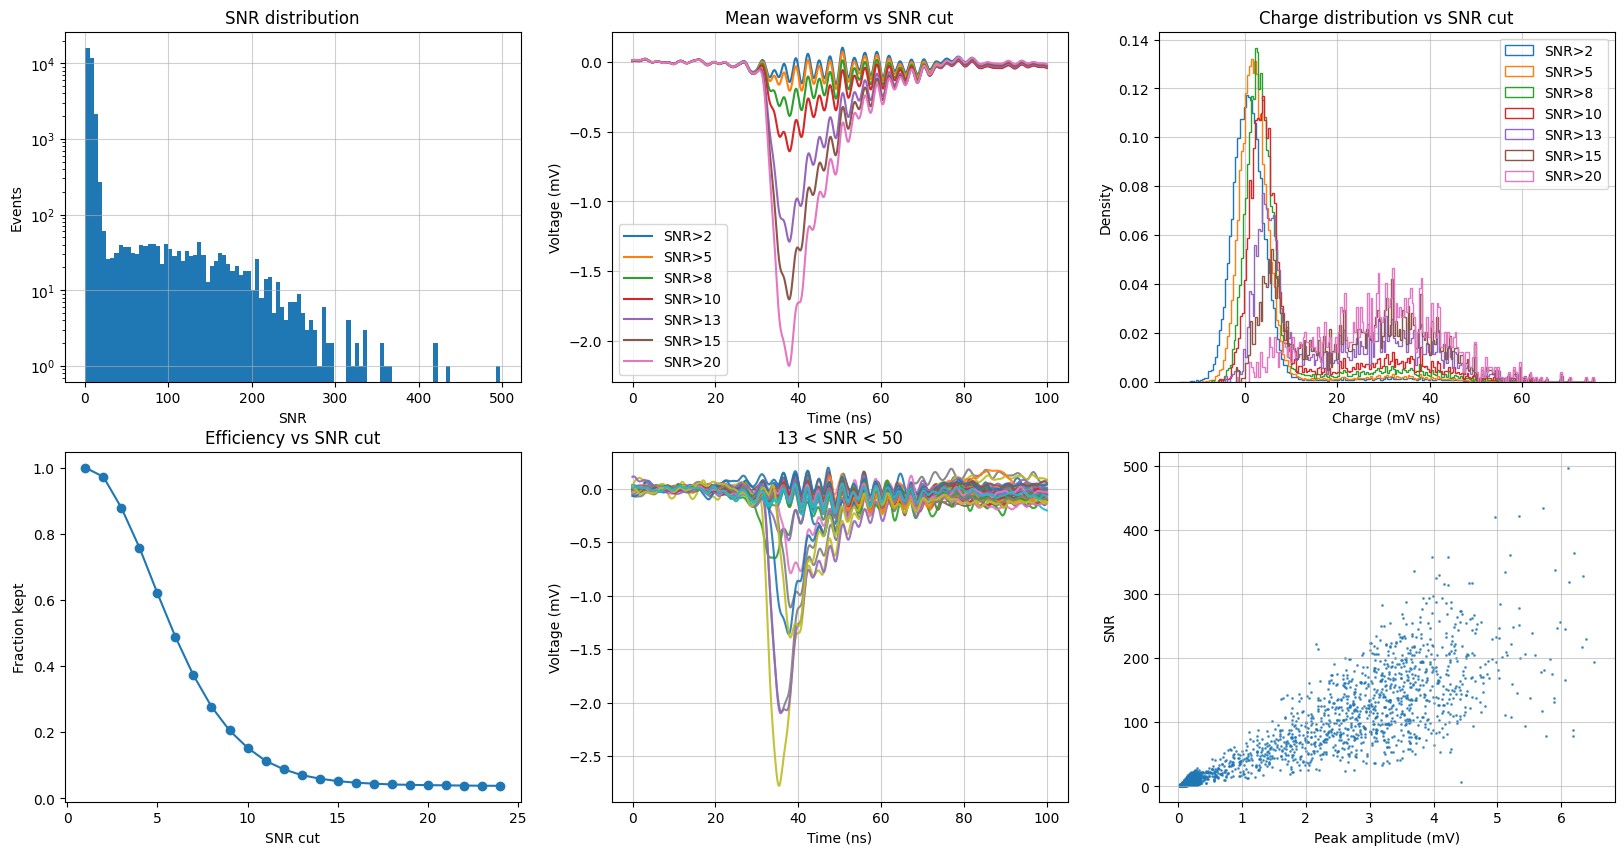

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df_sel)
plot_mean_waveforms_vs_snr(axes[1], df_sel, selected_waveforms, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df_sel, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df_sel, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df_sel, selected_waveforms, time_ns, snr_min=13, snr_max=50, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df_sel)  

# Charge Computation

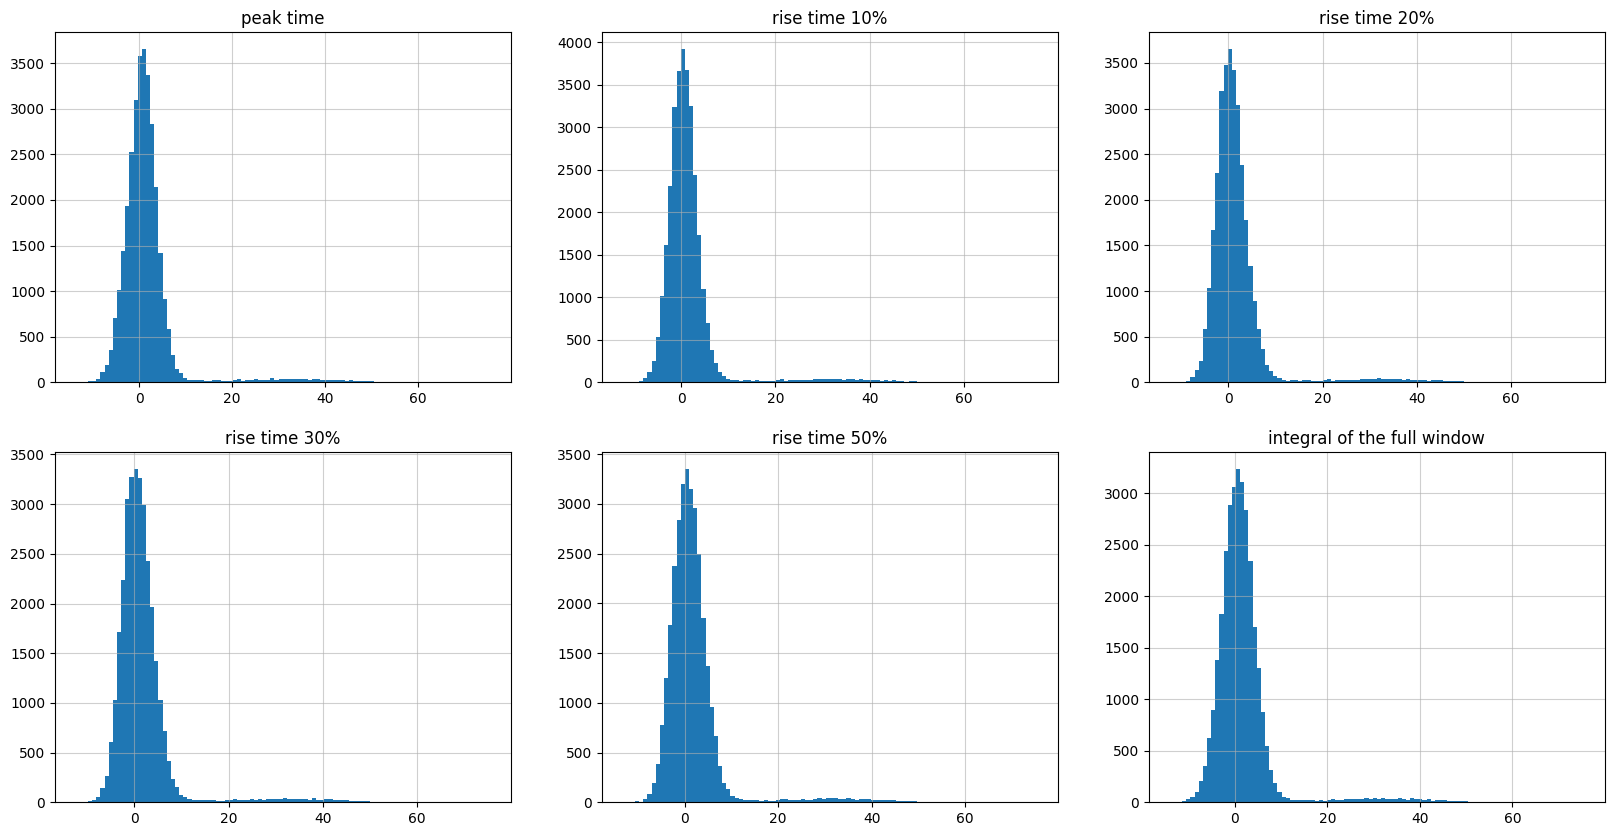

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

rg = None #(-20, 10)

axes[0].hist(df_sel.charge_peak_window_mV_ns, bins=100, range=rg);
axes[0].set_title("peak time")
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg);
axes[1].set_title("rise time 10%");
axes[2].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg);
axes[2].set_title("rise time 20%");
axes[3].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg);
axes[3].set_title("rise time 30%");
axes[4].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg);
axes[4].set_title("rise time 50%");
axes[5].hist(df_sel.area_mV_ns, bins=100, range=rg);
axes[5].set_title("integral of the full window");


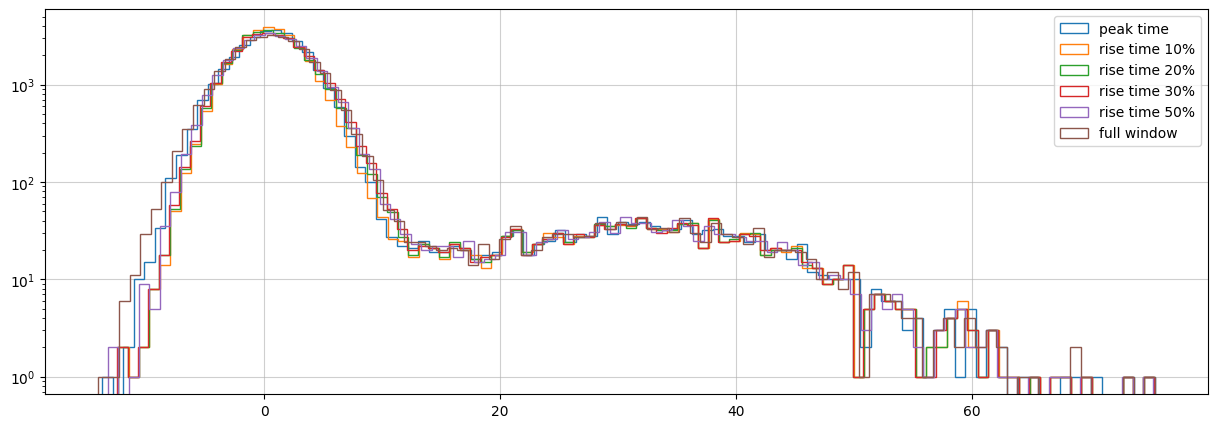

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();




# Pulse timing etc.

In [19]:
df_sel.columns

Index(['peak_time_ns', 'peak_idx', 'peak_amplitude_mV', 'fwhm_ns',
       'peak_width_ns', 'rise_time_10_90_ns', 'fall_time_90_10_ns',
       'cfd10_rise_ns', 'cfd20_rise_ns', 'cfd30_rise_ns', 'cfd50_rise_ns',
       'cfd90_rise_ns', 'cfd10_fall_ns', 'cfd20_fall_ns', 'cfd30_fall_ns',
       'cfd50_fall_ns', 'cfd90_fall_ns', 'area_mV_ns',
       'charge_peak_window_mV_ns', 'charge_cfd10_window_mV_ns',
       'charge_cfd20_window_mV_ns', 'charge_cfd30_window_mV_ns',
       'charge_cfd50_window_mV_ns', 'n_peaks', 'second_peak_time_ns',
       'second_peak_amplitude_mV', 'peak_separation_ns', 'event_id',
       'baseline_mean_mV', 'baseline_rms_mV', 'baseline_slope_mV_per_ns',
       'snr'],
      dtype='str')

cut efficiency:  0.038992201559688064


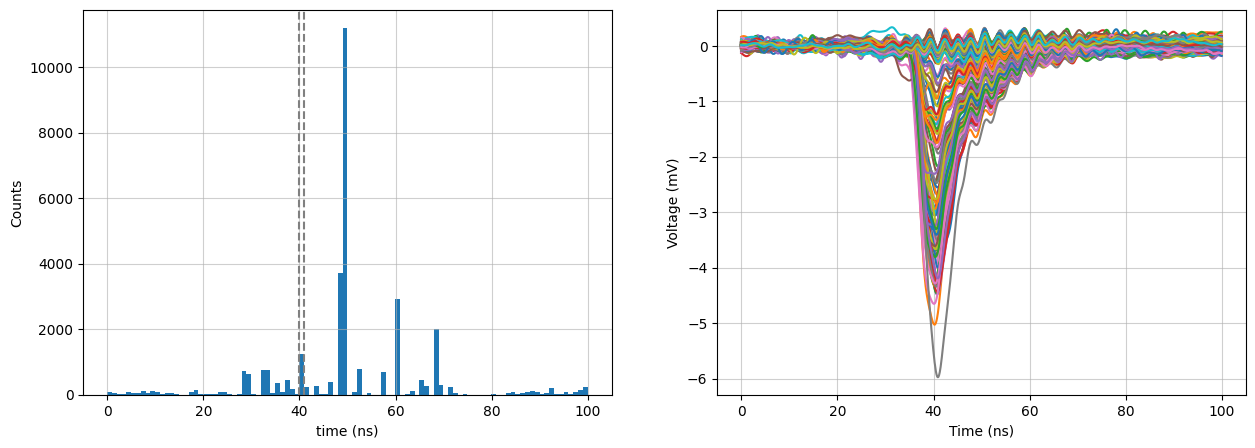

In [35]:
nEvts_plot = 1000

# win_ns = (48, 51) # noise
# win_ns = (59, 62) # noise
win_ns = (40, 41) # pulses

mask_keep = ( df_sel.peak_time_ns.between( win_ns[0], win_ns[1] ) )

df_cut = df_sel[mask_keep].copy()
sel_wfs = selected_waveforms[mask_keep.values]
print('cut efficiency: ', sel_wfs.shape[0]/selected_waveforms.shape[0])



fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes.ravel()

axes[0].hist(df_sel.peak_time_ns, bins=100);
axes[0].axvline(x = win_ns[0], color='gray', linestyle='dashed')
axes[0].axvline(x = win_ns[1], color='gray', linestyle='dashed')
axes[0].set_xlabel('time (ns)')
axes[0].set_ylabel('Counts')
add_plot_waveforms(axes[1], time_ns, sel_wfs[:nEvts_plot], title=f"")

cut efficiency:  0.003283553815552679


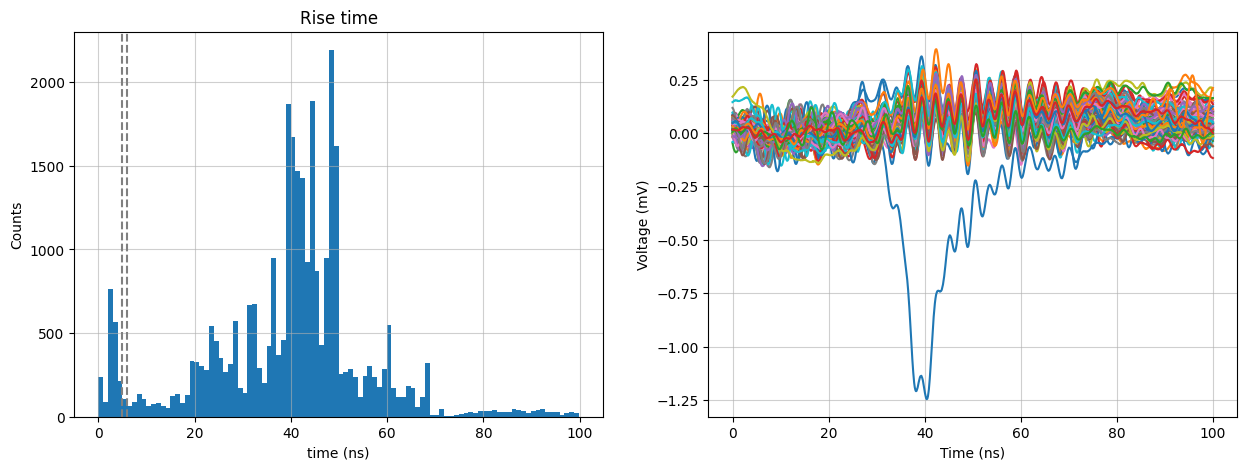

In [59]:
nEvts_plot = 1000

win_ns = (70, 100) # noise
win_ns = (47, 50) # noise
win_ns = (39, 45) # noise

win_ns = (2, 3) # waveforms
win_ns = (3, 4) # waveforms
win_ns = (4, 5) # waveforms
win_ns = (5, 6) # waveforms + lots of noise


mask_keep = ( df_sel.rise_time_10_90_ns.between( win_ns[0], win_ns[1] ) )

df_cut = df_sel[mask_keep].copy()
sel_wfs = selected_waveforms[mask_keep.values]
print('cut efficiency: ', sel_wfs.shape[0]/selected_waveforms.shape[0])


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes.ravel()
axes[0].hist(df_sel.rise_time_10_90_ns, bins=100);
axes[0].axvline(x = win_ns[0], color='gray', linestyle='dashed')
axes[0].axvline(x = win_ns[1], color='gray', linestyle='dashed')
axes[0].set_xlabel('time (ns)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Rise time')
add_plot_waveforms(axes[1], time_ns, sel_wfs[:nEvts_plot], title=f"")

cut efficiency:  0.00776686767909576


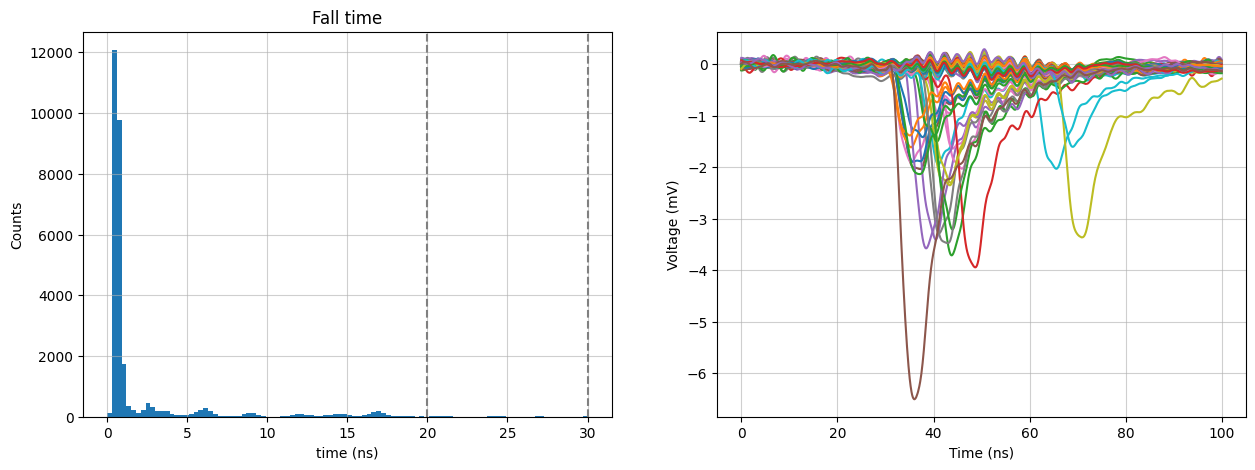

In [98]:
nEvts_plot = 1000

# win_ns = (0, 2) # fnoise
# win_ns = (2, 4) # noise
# win_ns = (5, 7) # noise + small ugly pulses
# win_ns = (8, 10) # noise + small ugly pulses
# win_ns = (11, 13) # pusles (more or less in time)
# win_ns = (14.5, 15) # pusles (more or less in time)
# win_ns = (16, 18) # pusles 
win_ns = (20, 30) # pusles 

mask_keep = ( df_sel.fall_time_90_10_ns.between( win_ns[0], win_ns[1] ) )

df_cut = df_sel[mask_keep].copy()
sel_wfs = selected_waveforms[mask_keep.values]
print('cut efficiency: ', sel_wfs.shape[0]/selected_waveforms.shape[0])


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes.ravel()

axes[0].hist(df_sel.fall_time_90_10_ns, bins=100, range=(0, 30));
axes[0].axvline(x = win_ns[0], color='gray', linestyle='dashed')
axes[0].axvline(x = win_ns[1], color='gray', linestyle='dashed')
axes[0].set_xlabel('time (ns)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Fall time')
add_plot_waveforms(axes[1], time_ns, sel_wfs[:nEvts_plot], title=f"")